<a href="https://colab.research.google.com/github/Fatimalbasha/KAUST-Labs2026/blob/main/Stage2/Day_1/Day1_Lab1_Understanding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 📌 **Common Transformer Classes**

##🔹`sklearn.preprocessing`
`sklearn.preprocessing` provides tools for **preprocessing and transforming tabular data** before training machine learning models.

In [ ]:
import pandas as pd

categories = pd.DataFrame({"Animal": ['cat', 'dog', 'cat', 'bird', 'dog']})

print("Before encoding: ")
categories

Before encoding: 


,Animal
0,cat
1,dog
2,cat
3,bird
4,dog


# 🔸 **OneHotEncoder**
sklearn.preprocessing.OneHotEncoder is a transformer used to convert categorical features into binary (one-hot) vectors.

Each category is represented by a separate column, with values of 0 or 1, ensuring that no artificial ordering is introduced.

Main Functions:

fit(X): learns the unique categories for each feature

transform(X): converts categories into one-hot encoded vectors

fit_transform(X): fits the encoder and transforms the data in one step

In [ ]:
from sklearn.preprocessing import OneHotEncoder #import OneHotEncoder

onehot_encoder = OneHotEncoder(sparse_output= False) # Instantiate OneHotEncoder

# sparse_output=False means:
# -Output will be a NumPy array
# -Easier to print and understand in labs

# 💡 Default behavior:
# sparse_output=True → sparse matrix (memory efficient)
# For teaching/labs → False is clearer


data_onehot_encoded = onehot_encoder.fit_transform(categories) # Apply fit_transform to the copied

# 🔹fit(categories)
# Looks at the column
# Learns unique categories
# ['bird', 'cat', 'dog']
# scikit-learn sorts them alphabetically by default

# 🔹transform(categories)
# Converts each row into binary vector

print('\nData after encoding:\n', data_onehot_encoded) #show after encoding



Data after encoding:
 [[0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]]


# **🔸 LabelEncoder**
sklearn.preprocessing.LabelEncoder is a transformer used to convert categorical labels into numerical values by assigning a unique integer to each category.

**Main Functions:**

fit(y): learns the unique categories from the target labels

transform(y): converts categories into numerical labels

fit_transform(y): fits the encoder and transforms the labels in one step

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder() # Instantiate LabelEncoder

data_label_encoded = label_encoder.fit_transform(categories["Animal"]) # Apply fit_transform to the column

print('\nData after encoding:\n', data_label_encoded) #show after encoding

# 🔹fit(y)
# Looks at the column
# Learns unique categories
# ['bird', 'cat', 'dog']
# scikit-learn sorts them alphabetically by default

# 🔹 transform(y)
# Assigns integers starting from 0:

# Category	Encoded value
#  bird	           0
#  cat	             1
#  dog             	2


Data after encoding:
 [1 2 1 0 2]


### 🔸 **StandardScaler**
`sklearn.preprocessing.StandardScaler` is a transformer used to **standardize features** by removing the mean and scaling to unit variance.

**Main Functions:**
- **fit(X)**: computes the mean and standard deviation for each feature  
- **transform(X)**: scales the data using the learned statistics (for test data)
- **fit_transform(X)**: fits the scaler and transforms the data in one step (for train data)

In [ ]:
data_for_scale = pd.DataFrame({"Feature_1": [11, 40, 19,12],"Feature_2": [2384, 439, 3282,576]})

print("Before scaling:")
data_for_scale

Before scaling:


,Feature_1,Feature_2
0,11,2384
1,40,439
2,19,3282
3,12,576


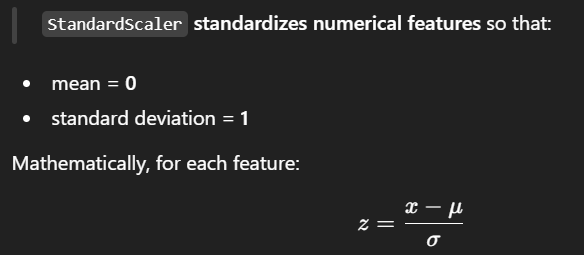

In [ ]:
from sklearn.preprocessing import StandardScaler

standard_scaler = StandardScaler() # Instantiate StandardScaler

data_standard_scaled = standard_scaler.fit_transform(data_for_scale) # Apply fit_transform

#🔹 Step 1: fit(X)
# For Feature_1
# Values: [11, 40, 19, 12]
# Mean ≈ 20.5
# Std ≈ 17.34

# For Feature_2
# Values: [2384, 439, 3282, 576]
# Mean ≈ 1670.25
# Std ≈ 1190.86

# 🔹Step 2: transform(X)
# Each value becomes:
# do the formula for each feature

print('\nData after scaling:\n', data_standard_scaled) #show after scaling


Data after scaling:
 [[-0.81387058  0.5916905 ]
 [ 1.67057645 -1.02069202]
 [-0.12850588  1.33612213]
 [-0.72819999 -0.90712061]]


### 🔸 **MinMaxScaler**
`sklearn.preprocessing.MinMaxScaler` is a transformer used to **scale features to a fixed range**, typically between 0 and 1.

**Main Functions:**
- **fit(X)**: computes the minimum and maximum value for each feature  
- **transform(X)**: scales the data to the specified range using the learned values (for test data)  
- **fit_transform(X)**: fits the scaler and transforms the data in one step (for train data)

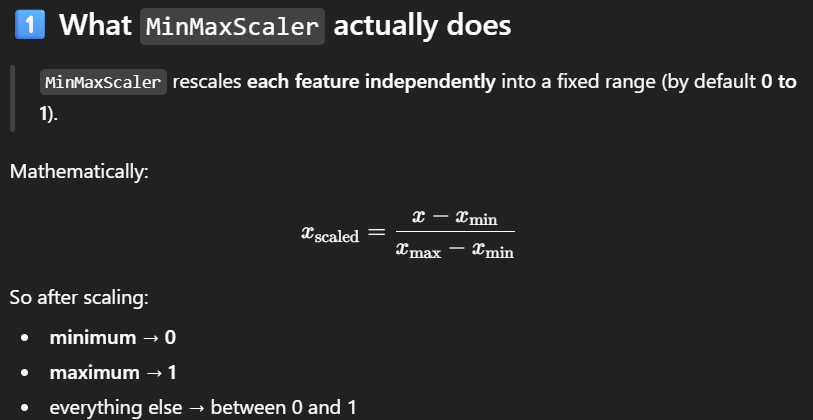

In [ ]:
from sklearn.preprocessing import MinMaxScaler

print("Before scaling: \n", data_for_scale)

minmax_scalar = MinMaxScaler() # Instantiate MinMaxScaler

data_minmax_scaled = minmax_scalar.fit_transform(data_for_scale) # Apply fit_transform to the copied

# 🔹 Step 1: fit(X)
# Learns min and max per feature.

# Feature_1
# min = 11
# max = 40

# Feature_2
# min = 439
# max = 3282


# 🔹Step 2: transform(X)
# Each value becomes:
# do the formula for each feature


print('\nData after scaling:\n', data_minmax_scaled) # show after scaling

Before scaling: 
    Feature_1  Feature_2
0         11       2384
1         40        439
2         19       3282
3         12        576

Data after scaling:
 [[0.         0.68413648]
 [1.         0.        ]
 [0.27586207 1.        ]
 [0.03448276 0.04818853]]




---


## 📌 **Data Splitting Strategies**


We can use `sklearn.model_selection` splitters to:
- Simulate **unseen (future) data**
- Evaluate model **generalization**
- Detect **overfitting**
- Avoid evaluating the model on data it has already seen


In [ ]:
import numpy as np

np.random.seed(42) # Ensures same results every run

X_reg = pd.DataFrame({"Feature_1": np.random.randn(500)})

y_reg = 3 * X_reg["Feature_1"] + np.random.randn(500) * 0.5
# True relationship: y = 3x
# Noise added: + random noise
# So:
# y_reg is continuous
# This is a regression problem

X_clf = pd.DataFrame({"Feature_1": np.random.randn(500)})

y_clf = (X_clf["Feature_1"] > 0).astype(int)
# Result:
# True → 1
# False → 0
# y_clf ∈ {0,1}
# Discrete labels → classification



##  1️⃣  `train_test_split`

<img src="https://media.geeksforgeeks.org/wp-content/uploads/20250917175411543155/dataset.webp" width="60%">

`train_test_split` divides the dataset into two separate parts:
- **Training set**: used to train the model  
- **Test set**: used to evaluate the model on unseen data  

Common split ratios include:
- **80% training / 20% testing**
- **70% training / 30% testing**







In [ ]:
from sklearn.model_selection import train_test_split
# train_test_split randomly splits your dataset into:
# Training set → the model learns
# Test set → the model is evaluated

X, y = X_clf.copy(), y_clf.copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, # Split features and labels together
    y,
    test_size = 0.2, # 20% → test set, 80% → training set
    random_state = 42, # Fixes randomness, Guarantees same split every run
    shuffle = True, # Randomly shuffles data before splitting, Prevents biased splits (e.g., sorted data), This is the default, but explicitly writing it shows understanding.
    stratify = y, # Preserves class proportions, Prevents losing a class in train or test
)

# Example:
# If original y has:
# 50% class 0
# 50% class 1
# Then both train and test keep that ratio
# Use stratify=y only for classification, not regression

# Print shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (400, 1)
X_test shape: (100, 1)
y_train shape: (400,)
y_test shape: (100,)


## 2️⃣ `KFold`

<img src="https://towardsdatascience.com/wp-content/uploads/2021/01/1AAwIlHM8TpAVe4l2FihNUQ.png" width="60%">


**K-Fold Cross Validation** splits the dataset into **K equal folds**.

- The model is trained on **K−1 folds**
- The remaining fold is used for testing
- This process is repeated **K times**
- Final performance is the **average** across all folds

K-Fold provides a more reliable evaluation, especially for **small datasets**.


In [ ]:
from sklearn.model_selection import KFold
# K-Fold CV evaluates a model multiple times on different train/test splits and averages the result.

# Use previously generated random data (example: regression data)
X, y = X_reg.copy(), y_reg.copy()

# Define K-Fold Cross Validation
kf = KFold( n_splits= 5, shuffle= True, random_state= 42)
# Dataset is split into 5 equal folds
# Each fold ≈ 20% of the data
# Total iterations = 5
#  random_state= 42 → Same folds every run

# Iterate through folds
for fold, (train_idx, test_idx) in enumerate(kf.split(X), start=1):
# What kf.split(X) returns:
# For each fold:
# train_idx → indices for training
# test_idx → indices for testing
# ⚠️ Notice: KFold works with indices, NOT data

# Why enumerate(..., start=1)?
#Just for nice printing
# Fold numbers: 1, 2, 3, 4, 5

# example:
# (1, (train_idx, test_idx))
# (2, (train_idx, test_idx))

# “For each split produced by KFold:
# store the fold number in fold
# store training indices in train_idx
# store testing indices in test_idx”

  # indexing for each fold
  X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
  y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

  # print shape
  print(f"Fold {fold}")
  print("  X_train shape:", X_train.shape)
  print("  X_test shape :", X_test.shape)
  print("  y_train shape:", y_train.shape)
  print("  y_test shape :", y_test.shape)
  print("-" * 30)



Fold 1
  X_train shape: (400, 1)
  X_test shape : (100, 1)
  y_train shape: (400,)
  y_test shape : (100,)
------------------------------
Fold 2
  X_train shape: (400, 1)
  X_test shape : (100, 1)
  y_train shape: (400,)
  y_test shape : (100,)
------------------------------
Fold 3
  X_train shape: (400, 1)
  X_test shape : (100, 1)
  y_train shape: (400,)
  y_test shape : (100,)
------------------------------
Fold 4
  X_train shape: (400, 1)
  X_test shape : (100, 1)
  y_train shape: (400,)
  y_test shape : (100,)
------------------------------
Fold 5
  X_train shape: (400, 1)
  X_test shape : (100, 1)
  y_train shape: (400,)
  y_test shape : (100,)
------------------------------


## 3️⃣ `StratifiedKFold`
<img src="https://dataaspirant.com/wp-content/uploads/2020/12/8-Stratified-K-Fold-Cross-Validation.png" width="50%">




**Stratified K-Fold** is a variation of K-Fold Cross Validation that **preserves the class distribution** in each fold.

- Each fold has the **same class proportions** as the original dataset
- important for **classification problems**
- Ensures fair and reliable evaluation when classes are imbalanced



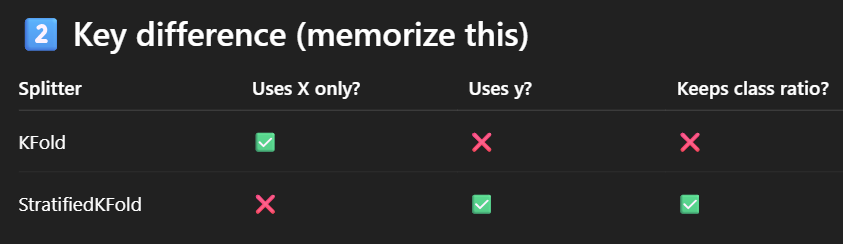

In [ ]:
# Problem in classification:
# You might get a fold with mostly class 1
# Or even no samples of class 0
# → evaluation becomes unfair and unstable
# 👉 StratifiedKFold fixes this

from sklearn.model_selection import StratifiedKFold

X, y = X_clf.copy(), y_clf.copy()

# Show full dataset class distribution
full_ratio = (y.value_counts(normalize = True) * 100).sort_index()
# y.value_counts() → Counts samples per class.
# normalize=True → Returns proportions instead of counts.
# * 100 → Converts to percentages
# .sort_index() → Ensures class order (0 then 1)

# Example output → {0: 45.20%, 1: 54.80%}
print("Full Dataset Class Distribution")
print("  y class percentages:", {k: f"{v:.2f}%" for k, v in full_ratio.items()})
print("-" * 40)


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Stratified K-Fold Cross Validation\n" + "-"*40)


for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start = 1):
  # Why skf.split(X, y)?
  # X → samples
  # y → tells StratifiedKFold how to balance classes

  X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
  y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

  print(f"Fold {fold}")
  print("  X_train shape:", X_train.shape)
  print("  X_test shape :", X_test.shape)
  print("  y_train shape:", y_train.shape)
  print("  y_test shape :", y_test.shape)

  # showing class distribution
  train_ratio = (y_train.value_counts(normalize = True) * 100).sort_index()
  test_ratio = (y_test.value_counts(normalize = True) * 100).sort_index()
  # 💡 Small differences are normal due to rounding,
  # but distribution is preserved.

  # So train_ratio looks like a dictionary-like object (actually a pandas Series):
  # {0: 45.25, 1: 54.75}

  print("  y_train class percentages:", {k: f"{v:.2f}%" for k, v in train_ratio.items()})
  print("  y_test class percentages :", {k: f"{v:.2f}%" for k, v in test_ratio.items()})
  print("-" * 40)




Full Dataset Class Distribution
  y class percentages: {0: '45.20%', 1: '54.80%'}
----------------------------------------
Stratified K-Fold Cross Validation
----------------------------------------
Fold 1
  X_train shape: (400, 1)
  X_test shape : (100, 1)
  y_train shape: (400,)
  y_test shape : (100,)
  y_train class percentages: {0: '45.25%', 1: '54.75%'}
  y_test class percentages : {0: '45.00%', 1: '55.00%'}
----------------------------------------
Fold 2
  X_train shape: (400, 1)
  X_test shape : (100, 1)
  y_train shape: (400,)
  y_test shape : (100,)
  y_train class percentages: {0: '45.25%', 1: '54.75%'}
  y_test class percentages : {0: '45.00%', 1: '55.00%'}
----------------------------------------
Fold 3
  X_train shape: (400, 1)
  X_test shape : (100, 1)
  y_train shape: (400,)
  y_test shape : (100,)
  y_train class percentages: {0: '45.25%', 1: '54.75%'}
  y_test class percentages : {0: '45.00%', 1: '55.00%'}
----------------------------------------
Fold 4
  X_train shap



---


## 📌 **Common Predictor Classes**
scikit-learn organizes machine learning models by **model families**, such as linear models, tree-based models, ensemble models, neighbors-based models, and support vector machines (SVM).


## 1️⃣ `sklearn.linear_model`

`sklearn.linear_model` provides **linear models** for regression and classification tasks.

Predictor classes in `sklearn.linear_model` share the following common functions:
- **fit(X, y)**: learns the model parameters from the training data  
- **predict(X)**: generates class labels or continuous predictions  
- **predict_proba(X)**: returns the predicted probability for each class (classification only)


### 🔹 **Linear Regression**


In [ ]:
# Import base linear model for regression (Linear Regression)
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Use previously generated random regression data
X, y = X_reg.copy(), y_reg.copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size= 0.2,
    random_state= True,
    shuffle = True
)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

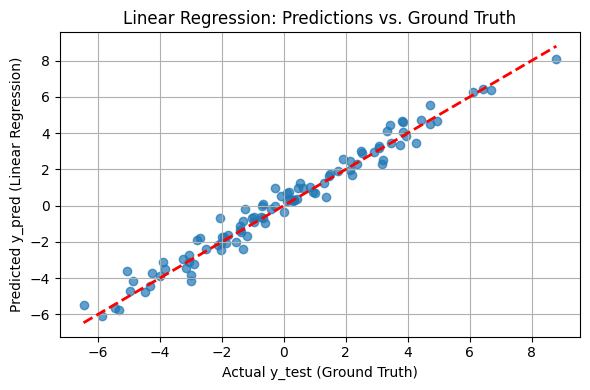

In [ ]:
# Plot for Linear Regression Predictions vs. Ground Truth
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.7)
# x-axis = actual values (y_test)
# y-axis = predicted values (y_pred)
# alpha=0.7 makes points slightly transparent (easier to see overlaps)

plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--', linewidth=2)
plt.xlabel("Actual y_test (Ground Truth)")
plt.ylabel("Predicted y_pred (Linear Regression)")
plt.title("Linear Regression: Predictions vs. Ground Truth")
plt.grid(True)

plt.tight_layout() # fixes spacing so labels don’t overlap
plt.show()

### 🔹 **Logistic Regression**


In [ ]:
# Import base linear model for classification (Logistic Regression)
from sklearn.linear_model import LogisticRegression

# Use previously generated random classification data
X, y = X_clf.copy(), y_clf.copy()

# split ratio (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% for test, remaining 80% for train
    random_state=42,      # reproducible output
    shuffle=True,         # representative splits
    stratify=y            # preserve class distribution
)

model = LogisticRegression()     # instantiate
model.fit(X_train, y_train)      # fit
y_pred = model.predict(X_test)   # predict


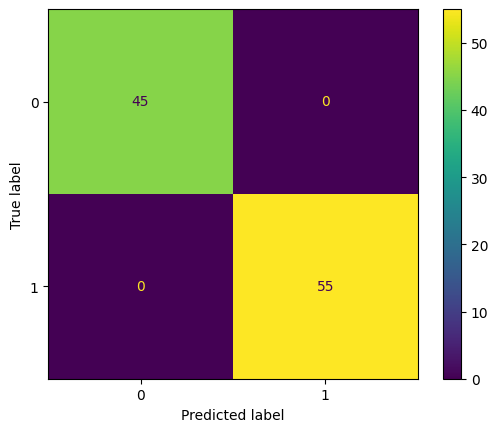

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
# Compares:
# True labels (y_test)
# Predicted labels (y_pred)
# labels=model.classes_ ensures:
# Correct order of classes (e.g. [0, 1])


# use ConfusionMatrixDisplay for visualization
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

disp.plot()
plt.show()

# [[TN, FP],
# [FN, TP]]


In [ ]:
# Interpretation:

# True Negatives (TN) = 45
# → class 0 correctly predicted as 0

# False Positives (FP) = 0
# → class 0 wrongly predicted as 1

# False Negatives (FN) = 0
# → class 1 wrongly predicted as 0

# True Positives (TP) = 55
# → class 1 correctly predicted as 1

## 2️⃣ `sklearn.tree`

`sklearn.tree` provides **tree-based models** for regression and classification tasks. They can model **non-linear relationships** and work well with tabular data.

Predictor classes in `sklearn.tree` share the following common functions:
- **fit(X, y)**: learns decision rules from the training data  
- **predict(X)**: generates class labels or continuous predictions  
- **predict_proba(X)**: returns the predicted probability for each class (classification only)



### 🔹 **DecisionTreeRegressor**


In [ ]:
# Import tree-based model for regression (Decision Tree Regressor)
from sklearn.tree import DecisionTreeRegressor

# Use previously generated random regression data
X, y = X_reg.copy(), y_reg.copy()

# Split ratio (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,shuffle=True)

# Train Decision Tree Regressor
model = DecisionTreeRegressor(random_state=42)  # instantiate
# random_state=42 fixes randomness in:
# feature selection
# split choices

model.fit(X_train, y_train)                     # fit
# The tree repeatedly:
# chooses a feature
# chooses a split point
# minimizes prediction error (MSE by default)
# Splitting continues until stopping criteria are met
# 💡 Unlike Linear Regression:
# No formula like y = wx + b
# Just nested if–else decisions

y_pred = model.predict(X_test)                  # predict
# For each test sample:
# traverse the tree
# land in a leaf
# output the mean value of that leaf


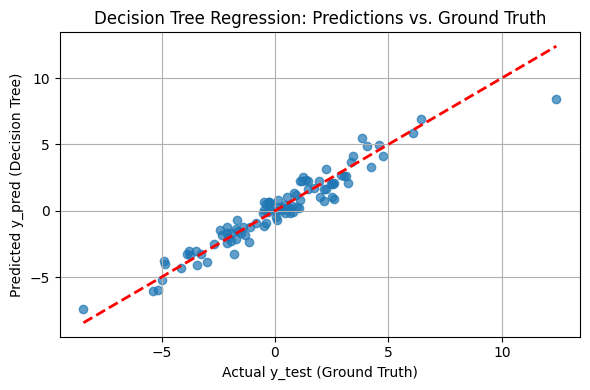

In [ ]:
# Plot for Decision Tree Regression Predictions vs. Ground Truth
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([min(y_test), max(y_test)],
         [min(y_test), max(y_test)],
         'r--', linewidth=2)

plt.xlabel("Actual y_test (Ground Truth)")
plt.ylabel("Predicted y_pred (Decision Tree)")
plt.title("Decision Tree Regression: Predictions vs. Ground Truth")
plt.grid(True)

plt.tight_layout()
plt.show()

Compared to Linear Regression:

Decision Tree can:

fit non-linear patterns

fit noise very well

Often very accurate on training data

Risk of overfitting

In your plot:

Points closely follow the diagonal → good performance

Slight deviations are normal due to noise

### 🔹 **DecisionTreeClassifier**


DecisionTreeClassifier is a tree-based classification model that learns if–else rules to predict class labels.

Key ideas:

Used for classification

Can model non-linear decision boundaries

Does not need feature scaling

High risk of overfitting if unrestricted

In [ ]:
# Import tree-based model for classification (Decision Tree Classifier)
from sklearn.tree import DecisionTreeClassifier

# Use previously generated random classification data
X, y = X_clf.copy(), y_clf.copy()

# Split ratio (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,shuffle=True)

# ⚠️ Note:
# You could add stratify=y (best practice for classification), but the code still works without it here.

# Train Decision Tree Classifier
model = DecisionTreeClassifier(random_state=42) # instantiate
model.fit(X_train, y_train)                     # fit
y_pred = model.predict(X_test)                  # predict

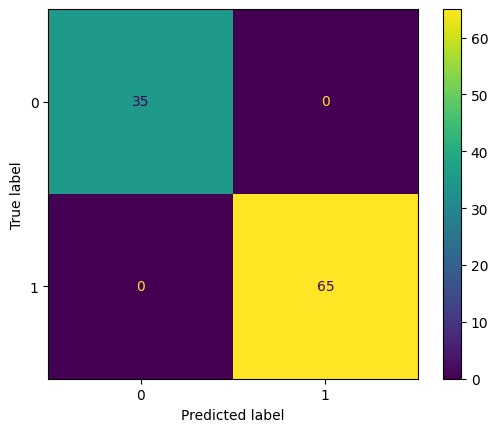

In [ ]:
# lets use confusion matrix to visualize the predictions
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

# use ConfusionMatrixDisplay for visualization
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

disp.plot()
plt.show()

In [ ]:
# True Negatives (TN) = 35
# → class 0 correctly predicted as 0

# False Positives (FP) = 0
# → class 0 wrongly predicted as 1

# False Negatives (FN) = 0
# → class 1 wrongly predicted as 0

# True Positives (TP) = 65
# → class 1 correctly predicted as 1



---


## 📌 **Evaluation Metrics**



`sklearn.metrics` provides tools used to **measure how well a model performs** on unseen data.

- Metrics compare the model’s predictions with the true labels  
- They help determine whether the model has **learned useful patterns**  
- Different tasks require different metrics:
  - **Regression** → MSE, MAE, RMSE
  - **Classification** → Accuracy, Percision, Recall, F1 Score

Choosing the correct metric is essential for proper model evaluation.


### 🔹 **Regression Metrics**


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

print("Regression Metrics\n" + "-"*30)

# Use previously generated random classification data
X, y = X_reg.copy(), y_reg.copy()

# Split ratio (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,shuffle=True)

# Train a regression model
reg_model = LinearRegression()
reg_model.fit(X_train, y_train)
y_pred = reg_model.predict(X_test)

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("MSE :", mse)
print("MAE :", mae)
print("RMSE:", rmse)

Regression Metrics
------------------------------
MSE : 0.2724531844231776
MAE : 0.4079602988629547
RMSE: 0.5219704823293915


### 🔹 **Classification Metrics**


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("\nClassification Metrics\n" + "-"*30)

# Use previously generated random classification data
X, y = X_clf.copy(), y_clf.copy()

# Split ratio (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,shuffle=True)

# Train a classification model
clf_model = LogisticRegression()
clf_model.fit(X_train, y_train)
y_pred = clf_model.predict(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)



Classification Metrics
------------------------------
Accuracy : 0.99
Precision: 1.0
Recall   : 0.9846153846153847
F1 Score : 0.9922480620155039


The **classification report** provides a detailed evaluation of a classification model. It summarizes key metrics: Precision, Recall, F1 Score, and support

In [ ]:
from sklearn.metrics import classification_report

# Generate classification report
report = classification_report(y_test, y_pred)

print("Classification Report\n" + "-"*30)
print(report)

Classification Report
------------------------------
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        35
           1       1.00      0.98      0.99        65

    accuracy                           0.99       100
   macro avg       0.99      0.99      0.99       100
weighted avg       0.99      0.99      0.99       100



Row: class 0
What this means in human language:

There are 35 real samples of class 0

Recall = 1.00

The model found ALL class 0 samples

❌ No class 0 was missed

Precision = 0.97

When the model predicted 0, it was correct 97% of the time

❗ A few predictions of 0 were actually wrong

F1 = 0.99

Very strong balance

📌 Sentence you can say in the exam:

“For class 0, the model achieved perfect recall and high precision.”


------------
Row: class 1
Meaning:

There are 65 real samples of class 1

Precision = 1.00

Every time the model predicted 1, it was always correct

❌ No false positives

Recall = 0.98

The model missed a small number of real 1s

F1 = 0.99

Very strong performance

📌 Exam sentence:

“For class 1, the model achieved perfect precision with slightly lower recall.”
------------------------------

-------------------------
Step 3: Accuracy row (overall performance)
Meaning:

Out of 100 test samples

The model classified 99 correctly

📌 Important:

Accuracy ignores class balance

That’s why we also look at precision/recall
-------------------------------
Step 4: Macro average
Macro average = simple average across classes
Key idea:

Treats all classes equally

Does NOT care how many samples each class has

📌 When to mention macro avg:

“Macro average is useful when all classes are equally important.”

-------------------------------------
What does weighted mean?

Weighted average = average weighted by class size (support)

Class 1 has 65 samples → more influence
Class 0 has 35 samples → less influence

📌 When to mention weighted avg:

“Weighted average accounts for class imbalance.”

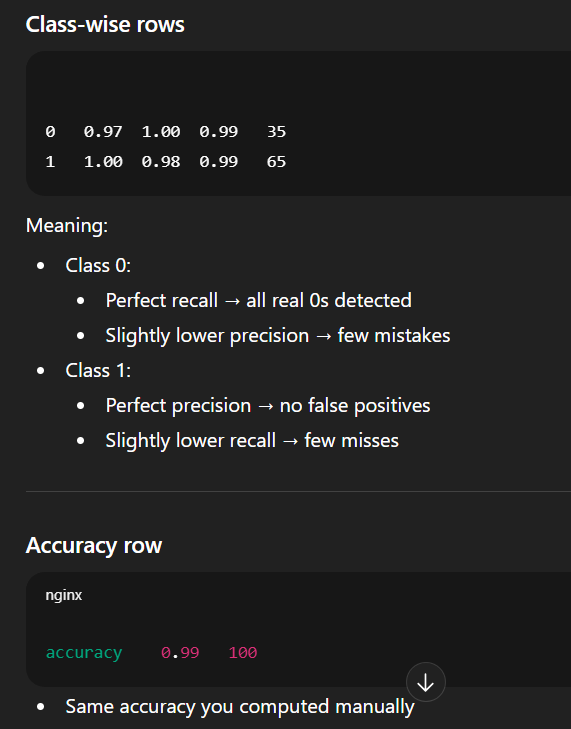 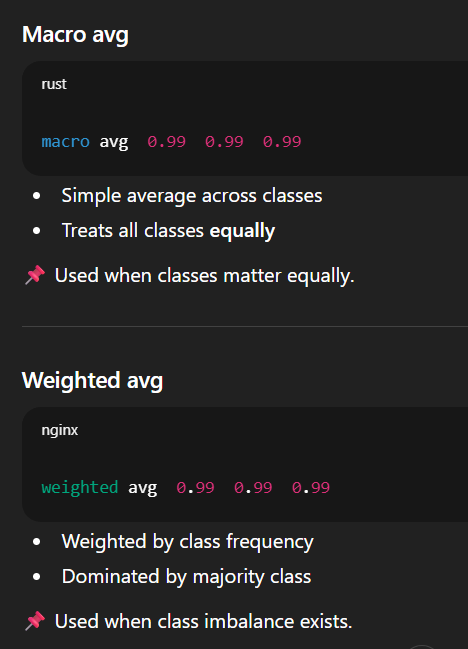

# **Now You Know the Core scikit-learn Classes and Functions**🚀


## Applying scikit-learn on a Real Dataset:  Academic Performance Prediction 📊

In this task, we use a simulated student lifestyle dataset to predict **final exam scores** based on daily habits such as study time, sleep, social media usage, and mental health 🧠📱


Dataset link: https://www.kaggle.com/datasets/jayaantanaath/student-habits-vs-academic-performance


Using Colab cache for faster access to the 'student-habits-vs-academic-performance' dataset.

Dataset Shapes
X: (1000, 15)
y: (1000,)

Model Evaluation Metrics (K-Fold)
----------------------------------------
MSE : 29.23
MAE : 4.29
RMSE: 5.41
----------------------------------------


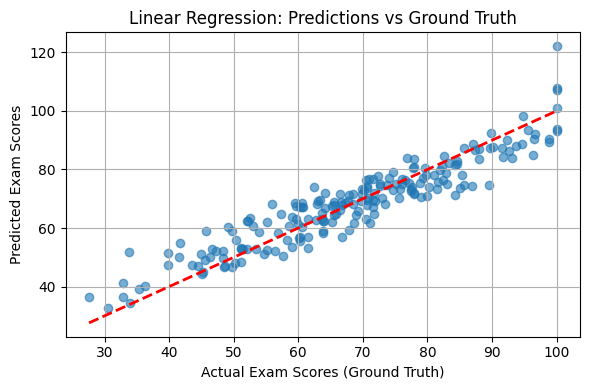

In [ ]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error


# Download dataset from Kaggle
path = kagglehub.dataset_download("jayaantanaath/student-habits-vs-academic-performance")

# Load CSV file
df = pd.read_csv(f"{path}/student_habits_performance.csv")

# Separate Features and Target
target_column = "exam_score"

X = df.drop(target_column, axis=1)
y = df[target_column]
# Default parameters: df.drop(labels, axis=0, inplace=False)
# axis=0 → drop rows
# axis=1 → drop column
# inplace=False → returns a new DataFrame, does NOT modify df

print("\nDataset Shapes")
print("X:", X.shape)
print("y:", y.shape)


# Encode Categorical Features
label_encoder = LabelEncoder()

for col in X.select_dtypes(include=["object"]).columns:
    X[col] = label_encoder.fit_transform(X[col])
# What it does: converts strings → integers per column

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# What it does: standardizes each column to mean 0 and std 1.


# Define Model
model = LinearRegression()

# K-Fold Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

mse_scores = []
mae_scores = []

for train_idx, test_idx in kf.split(X_scaled):
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Train model
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Evaluation metrics
    mse_scores.append(mean_squared_error(y_test, y_pred))
    mae_scores.append(mean_absolute_error(y_test, y_pred))

# Print Evaluation Metrics
print("\nModel Evaluation Metrics (K-Fold)\n" + "-"*40)
print(f"MSE : {np.mean(mse_scores):.2f}")
print(f"MAE : {np.mean(mae_scores):.2f}")
print(f"RMSE: {np.sqrt(np.mean(mse_scores)):.2f}")
print("-"*40)


# Plot Predictions vs Ground Truth
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    linewidth=2
)

plt.xlabel("Actual Exam Scores (Ground Truth)")
plt.ylabel("Predicted Exam Scores")
plt.title("Linear Regression: Predictions vs Ground Truth")
plt.grid(True)

plt.tight_layout()
plt.show()
